# CSCI E-89 Assignment 03 - Problem 3
### Author: Carlos Fernandez

Reproduces "Building an Image Classifier with PyTorch" (Chapter 10, *Hands-On Machine Learning with Scikit-Learn and PyTorch*, Geron, 2025) on Fashion-MNIST, and adds a plot of the training accuracy.

Code generated with Claude (claude.ai/code). Each code cell is labelled with the script it comes from.

In [1]:
import sys
sys.path.insert(0, 'scripts')

## step1_setup.py

**What was done and why:** Step 1: environment setup for the Fashion-MNIST MLP assignment.

Reproduces the setup portion of "Building an Image Classifier with PyTorch"
(Chapter 10, Hands-On Machine Learning with Scikit-Learn and PyTorch, Geron 2025):
fix random seeds for reproducibility and pick the best available device.

In [2]:
# ===== Notebook cell for generated script: scripts/step1_setup.py =====
"""Step 1: environment setup for the Fashion-MNIST MLP assignment.

Reproduces the setup portion of "Building an Image Classifier with PyTorch"
(Chapter 10, Hands-On Machine Learning with Scikit-Learn and PyTorch, Geron 2025):
fix random seeds for reproducibility and pick the best available device.
"""

import platform
import random

import numpy as np
import torch

SEED = 42


def set_seed(seed: int = SEED) -> None:
    """Fix the seed for the random, numpy, and torch RNGs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """Pick CUDA if available, else Apple MPS, else CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


if __name__ == "__main__":
    set_seed(SEED)
    device = get_device()

    print(f"Python version:  {platform.python_version()}")
    print(f"NumPy version:   {np.__version__}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"Seed:            {SEED}")
    print(f"Device:          {device}")


Python version:  3.11.15
NumPy version:   2.4.6
PyTorch version: 2.14.0+cu130
Seed:            42
Device:          cpu


## step2_data.py

**What was done and why:** Step 2: Fashion-MNIST data loading for the MLP classifier assignment.

Reproduces the data-loading portion of "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
load Fashion-MNIST, scale images to float32 in [0, 1], split the 60,000
training images into 55,000 train / 5,000 validation, and wrap everything
in DataLoaders. The test set is kept aside and must not influence any
training decision.

In [3]:
# ===== Notebook cell for generated script: scripts/step2_data.py =====
__file__ = r"scripts/step2_data.py"  # notebooks have no __file__, so define it here
"""Step 2: Fashion-MNIST data loading for the MLP classifier assignment.

Reproduces the data-loading portion of "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
load Fashion-MNIST, scale images to float32 in [0, 1], split the 60,000
training images into 55,000 train / 5,000 validation, and wrap everything
in DataLoaders. The test set is kept aside and must not influence any
training decision.
"""

from pathlib import Path

import torch
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2

SEED = 42
DATA_DIR = Path(__file__).resolve().parents[1] / "data"
BATCH_SIZE = 32
N_TRAIN = 55_000
N_VAL = 5_000

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

TRANSFORM = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)


def load_datasets(data_dir: Path = DATA_DIR):
    """Download (if needed) and return the raw train/test FashionMNIST datasets."""
    train_full = FashionMNIST(
        root=data_dir, train=True, download=True, transform=TRANSFORM
    )
    test = FashionMNIST(
        root=data_dir, train=False, download=True, transform=TRANSFORM
    )
    return train_full, test


def split_train_val(train_full, n_train: int = N_TRAIN, n_val: int = N_VAL, seed: int = SEED):
    """Split the full training set into train/validation subsets with a seeded generator."""
    generator = torch.Generator().manual_seed(seed)
    return random_split(train_full, [n_train, n_val], generator=generator)


def build_dataloaders(batch_size: int = BATCH_SIZE, data_dir: Path = DATA_DIR):
    """Load Fashion-MNIST, split it, and wrap the three subsets in DataLoaders."""
    train_full, test = load_datasets(data_dir)
    train, val = split_train_val(train_full)

    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


if __name__ == "__main__":
    train_loader, val_loader, test_loader = build_dataloaders()

    print(f"Train size:      {len(train_loader.dataset)}")
    print(f"Validation size: {len(val_loader.dataset)}")
    print(f"Test size:       {len(test_loader.dataset)}")

    images, labels = next(iter(train_loader))
    print(f"Batch images shape: {images.shape}, dtype: {images.dtype}")
    print(f"Batch labels shape: {labels.shape}, dtype: {labels.dtype}")
    print(f"Pixel value range:  [{images.min().item():.3f}, {images.max().item():.3f}]")
    print(f"Class names: {CLASS_NAMES}")


Train size:      55000
Validation size: 5000
Test size:       10000
Batch images shape: torch.Size([32, 1, 28, 28]), dtype: torch.float32
Batch labels shape: torch.Size([32]), dtype: torch.int64
Pixel value range:  [0.000, 1.000]
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## step3_model.py

**What was done and why:** Step 3: the 784-300-100-10 MLP classifier for Fashion-MNIST.

Reproduces the model definition from "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
a flatten layer followed by two hidden ReLU layers and a linear output
layer returning raw logits (no softmax, since CrossEntropyLoss expects
logits and applies log-softmax internally).

In [4]:
# ===== Notebook cell for generated script: scripts/step3_model.py =====
"""Step 3: the 784-300-100-10 MLP classifier for Fashion-MNIST.

Reproduces the model definition from "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
a flatten layer followed by two hidden ReLU layers and a linear output
layer returning raw logits (no softmax, since CrossEntropyLoss expects
logits and applies log-softmax internally).
"""

import torch
from torch import nn

EXPECTED_PARAM_COUNT = 266_610


class ImageClassifier(nn.Module):
    """784-300-100-10 MLP that returns raw logits over 10 classes."""

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(784, 300)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(100, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.hidden1(x))
        x = self.relu2(self.hidden2(x))
        return self.output(x)


def build_model() -> ImageClassifier:
    """Construct an ImageClassifier instance."""
    return ImageClassifier()


def count_parameters(model: nn.Module) -> int:
    """Total number of parameters (trainable and not) in the model."""
    return sum(p.numel() for p in model.parameters())


if __name__ == "__main__":
    model = build_model()
    print(model)

    batch_size = 32
    dummy_input = torch.rand(batch_size, 1, 28, 28)
    logits = model(dummy_input)
    print(f"Output shape: {tuple(logits.shape)}")
    assert logits.shape == (batch_size, 10), f"Unexpected output shape: {logits.shape}"

    n_params = count_parameters(model)
    print(f"Total parameters: {n_params}")
    assert n_params == EXPECTED_PARAM_COUNT, (
        f"Expected {EXPECTED_PARAM_COUNT} parameters, got {n_params}"
    )

    print("All assertions passed.")


ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (hidden2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=100, out_features=10, bias=True)
)
Output shape: (32, 10)
Total parameters: 266610
All assertions passed.


## step4_train.py

**What was done and why:** Step 4: manual training loop for the Fashion-MNIST MLP classifier.

Reproduces the training loop from "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
CrossEntropyLoss, plain SGD with lr=0.1, for exactly 10 epochs, tracking
train/validation loss and accuracy per epoch.

In [5]:
# ===== Notebook cell for generated script: scripts/step4_train.py =====
"""Step 4: manual training loop for the Fashion-MNIST MLP classifier.

Reproduces the training loop from "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
CrossEntropyLoss, plain SGD with lr=0.1, for exactly 10 epochs, tracking
train/validation loss and accuracy per epoch.
"""

import torch
from torch import nn

from step1_setup import get_device, set_seed
from step2_data import build_dataloaders
from step3_model import build_model

SEED = 42
LEARNING_RATE = 0.1
N_EPOCHS = 10


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Run one training epoch; return (avg_loss, accuracy)."""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate the model on a loader (no gradients); return (avg_loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, train_loader, val_loader, device, epochs=N_EPOCHS, lr=LEARNING_RATE):
    """Train for `epochs` epochs with SGD, printing one line per epoch.

    Returns a history dict with train_loss, train_acc, val_loss, val_acc lists.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:2d}/{epochs} - "
            f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
            f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
        )

    return history


if __name__ == "__main__":
    set_seed(SEED)
    device = get_device()
    print(f"Device: {device}")

    train_loader, val_loader, test_loader = build_dataloaders()
    model = build_model().to(device)

    history = train_model(model, train_loader, val_loader, device)

    print(f"Final validation accuracy: {history['val_acc'][-1]:.4f}")


Device: cpu


Epoch  1/10 - train_loss: 0.6061 - train_acc: 0.7814 - val_loss: 0.4475 - val_acc: 0.8424


Epoch  2/10 - train_loss: 0.4061 - train_acc: 0.8496 - val_loss: 0.4245 - val_acc: 0.8402


Epoch  3/10 - train_loss: 0.3630 - train_acc: 0.8661 - val_loss: 0.3969 - val_acc: 0.8494


Epoch  4/10 - train_loss: 0.3354 - train_acc: 0.8768 - val_loss: 0.3651 - val_acc: 0.8638


...

Epoch  6/10 - train_loss: 0.2994 - train_acc: 0.8867 - val_loss: 0.3608 - val_acc: 0.8640


Epoch  7/10 - train_loss: 0.2852 - train_acc: 0.8925 - val_loss: 0.3362 - val_acc: 0.8754


Epoch  8/10 - train_loss: 0.2743 - train_acc: 0.8962 - val_loss: 0.3366 - val_acc: 0.8748


Epoch  9/10 - train_loss: 0.2630 - train_acc: 0.9008 - val_loss: 0.3380 - val_acc: 0.8798


Epoch 10/10 - train_loss: 0.2525 - train_acc: 0.9042 - val_loss: 0.3333 - val_acc: 0.8766
Final validation accuracy: 0.8766


## step5_plot.py

**What was done and why:** Step 5: plot training/validation accuracy and loss curves.

Adds the training-accuracy plot requested for this assignment on top of the
book's chapter (accuracy per epoch alongside loss per epoch), saved to a PNG
so the learning curves can be inspected without rerunning training.

In [6]:
# ===== Notebook cell for generated script: scripts/step5_plot.py =====
__file__ = r"scripts/step5_plot.py"  # notebooks have no __file__, so define it here
"""Step 5: plot training/validation accuracy and loss curves.

Adds the training-accuracy plot requested for this assignment on top of the
book's chapter (accuracy per epoch alongside loss per epoch), saved to a PNG
so the learning curves can be inspected without rerunning training.
"""

from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

from step1_setup import get_device, set_seed
from step2_data import build_dataloaders
from step3_model import build_model
from step4_train import SEED, train_model

OUTPUT_PATH = Path(__file__).resolve().parent / "training_curves.png"


def plot_training_curves(history: dict, save_path: Path = OUTPUT_PATH) -> Path:
    """Plot accuracy and loss curves (train + val) side by side and save to `save_path`."""
    epochs = range(1, len(history["train_acc"]) + 1)

    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 5))

    ax_acc.plot(epochs, history["train_acc"], marker="o", label="Train accuracy")
    ax_acc.plot(epochs, history["val_acc"], marker="o", label="Validation accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title("Training and Validation Accuracy")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    ax_loss.plot(epochs, history["train_loss"], marker="o", label="Train loss")
    ax_loss.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title("Training and Validation Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(save_path)
    plt.close(fig)

    return save_path


if __name__ == "__main__":
    set_seed(SEED)
    device = get_device()
    print(f"Device: {device}")

    train_loader, val_loader, test_loader = build_dataloaders()
    model = build_model().to(device)

    history = train_model(model, train_loader, val_loader, device)

    saved_path = plot_training_curves(history)
    print(f"Saved training curves to {saved_path}")


Device: cpu


Epoch  1/10 - train_loss: 0.6061 - train_acc: 0.7814 - val_loss: 0.4475 - val_acc: 0.8424


Epoch  2/10 - train_loss: 0.4061 - train_acc: 0.8496 - val_loss: 0.4245 - val_acc: 0.8402


Epoch  3/10 - train_loss: 0.3630 - train_acc: 0.8661 - val_loss: 0.3969 - val_acc: 0.8494


Epoch  4/10 - train_loss: 0.3354 - train_acc: 0.8768 - val_loss: 0.3651 - val_acc: 0.8638


...

Epoch  6/10 - train_loss: 0.2994 - train_acc: 0.8867 - val_loss: 0.3608 - val_acc: 0.8640


Epoch  7/10 - train_loss: 0.2852 - train_acc: 0.8925 - val_loss: 0.3362 - val_acc: 0.8754


Epoch  8/10 - train_loss: 0.2743 - train_acc: 0.8962 - val_loss: 0.3366 - val_acc: 0.8748


Epoch  9/10 - train_loss: 0.2630 - train_acc: 0.9008 - val_loss: 0.3380 - val_acc: 0.8798


Epoch 10/10 - train_loss: 0.2525 - train_acc: 0.9042 - val_loss: 0.3333 - val_acc: 0.8766
Saved training curves to /home/user/csci-e89-hw03/prob3/scripts/training_curves.png


Plot saved by `step5_plot.py`, displayed here so it appears in the notebook and the HTML export:

scripts/training_curves.png


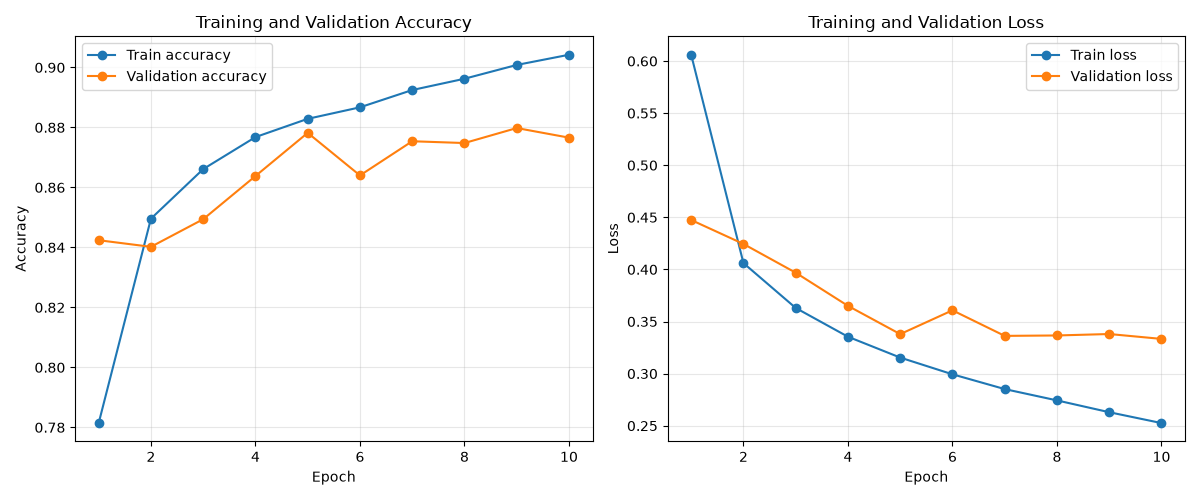

In [7]:
from IPython.display import Image, display
import glob
for f in sorted(glob.glob('scripts/*.png') + glob.glob('*.png')):
    print(f)
    display(Image(filename=f))

## step6_evaluate.py

**What was done and why:** Step 6: final test-set evaluation for the Fashion-MNIST MLP classifier.

Reproduces the final evaluation from "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
the test set is touched exactly once, after training, to report accuracy
and a handful of individual predictions with their softmax probabilities.

In [8]:
# ===== Notebook cell for generated script: scripts/step6_evaluate.py =====
"""Step 6: final test-set evaluation for the Fashion-MNIST MLP classifier.

Reproduces the final evaluation from "Building an Image Classifier with
PyTorch" (Chapter 10, Hands-On ML with Scikit-Learn and PyTorch, Geron 2025):
the test set is touched exactly once, after training, to report accuracy
and a handful of individual predictions with their softmax probabilities.
"""

import torch

from step1_setup import get_device, set_seed
from step2_data import CLASS_NAMES, build_dataloaders
from step3_model import build_model
from step4_train import SEED, evaluate, train_model

TOP_K = 3
N_SAMPLES = 3


@torch.no_grad()
def test_accuracy(model, test_loader, device) -> float:
    """Compute accuracy on the test set. Intended to be called once, after training."""
    criterion = torch.nn.CrossEntropyLoss()
    _, accuracy = evaluate(model, test_loader, criterion, device)
    return accuracy


@torch.no_grad()
def predict_samples(model, dataset, indices, device, class_names=CLASS_NAMES, top_k=TOP_K):
    """For each index into `dataset`, return the true/predicted class and top-k softmax probs."""
    model.eval()
    results = []

    for idx in indices:
        image, true_label = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1).squeeze(0)
        top_probs, top_classes = probs.topk(top_k)
        predicted_label = int(top_classes[0].item())

        results.append(
            {
                "index": idx,
                "true_class": class_names[true_label],
                "predicted_class": class_names[predicted_label],
                "top_k": [
                    (class_names[int(c)], float(p))
                    for p, c in zip(top_probs, top_classes)
                ],
            }
        )

    return results


if __name__ == "__main__":
    set_seed(SEED)
    device = get_device()
    print(f"Device: {device}")

    train_loader, val_loader, test_loader = build_dataloaders()
    model = build_model().to(device)

    train_model(model, train_loader, val_loader, device)

    acc = test_accuracy(model, test_loader, device)
    print(f"\nTest accuracy: {acc:.4f}")

    sample_indices = list(range(N_SAMPLES))
    predictions = predict_samples(model, test_loader.dataset, sample_indices, device)

    print(f"\nSample predictions (top-{TOP_K} softmax probabilities):")
    for pred in predictions:
        print(f"\n  Test image #{pred['index']}")
        print(f"    True class:      {pred['true_class']}")
        print(f"    Predicted class: {pred['predicted_class']}")
        for class_name, prob in pred["top_k"]:
            print(f"      {class_name:<14s} {prob:.4f}")


Device: cpu


Epoch  1/10 - train_loss: 0.6061 - train_acc: 0.7814 - val_loss: 0.4475 - val_acc: 0.8424


Epoch  2/10 - train_loss: 0.4061 - train_acc: 0.8496 - val_loss: 0.4245 - val_acc: 0.8402


Epoch  3/10 - train_loss: 0.3630 - train_acc: 0.8661 - val_loss: 0.3969 - val_acc: 0.8494


Epoch  4/10 - train_loss: 0.3354 - train_acc: 0.8768 - val_loss: 0.3651 - val_acc: 0.8638


...

Epoch  7/10 - train_loss: 0.2852 - train_acc: 0.8925 - val_loss: 0.3362 - val_acc: 0.8754


Epoch  8/10 - train_loss: 0.2743 - train_acc: 0.8962 - val_loss: 0.3366 - val_acc: 0.8748


Epoch  9/10 - train_loss: 0.2630 - train_acc: 0.9008 - val_loss: 0.3380 - val_acc: 0.8798


Epoch 10/10 - train_loss: 0.2525 - train_acc: 0.9042 - val_loss: 0.3333 - val_acc: 0.8766



Test accuracy: 0.8715

Sample predictions (top-3 softmax probabilities):

  Test image #0
    True class:      Ankle boot
    Predicted class: Ankle boot
      Ankle boot     0.9866
      Sneaker        0.0132
      Sandal         0.0002

  Test image #1
    True class:      Pullover
    Predicted class: Pullover
      Pullover       0.9991
      Coat           0.0005
      Shirt          0.0004

  Test image #2
    True class:      Trouser
    Predicted class: Trouser
      Trouser        1.0000
      T-shirt/top    0.0000
      Shirt          0.0000


## step7_save_load.py

**What was done and why:** Step 7: save/load the Fashion-MNIST MLP checkpoint.

Saves the model's state_dict together with its constructor
hyperparameters, reloads the checkpoint with torch.load(weights_only=True)
(the safe-unpickling mode), and asserts the reloaded model produces
identical outputs to the original.

In [9]:
# ===== Notebook cell for generated script: scripts/step7_save_load.py =====
__file__ = r"scripts/step7_save_load.py"  # notebooks have no __file__, so define it here
"""Step 7: save/load the Fashion-MNIST MLP checkpoint.

Saves the model's state_dict together with its constructor
hyperparameters, reloads the checkpoint with torch.load(weights_only=True)
(the safe-unpickling mode), and asserts the reloaded model produces
identical outputs to the original.
"""

from pathlib import Path

import torch

from step1_setup import get_device, set_seed
from step3_model import ImageClassifier, build_model

SEED = 42
CHECKPOINT_PATH = Path(__file__).resolve().parent / "model_checkpoint.pt"

HYPERPARAMETERS = {
    "input_size": 784,
    "hidden1_size": 300,
    "hidden2_size": 100,
    "num_classes": 10,
}


def save_checkpoint(model: ImageClassifier, path: Path = CHECKPOINT_PATH, hyperparameters: dict = HYPERPARAMETERS) -> Path:
    """Save the model's state_dict plus its constructor hyperparameters."""
    checkpoint = {
        "state_dict": model.state_dict(),
        "hyperparameters": hyperparameters,
    }
    torch.save(checkpoint, path)
    return path


def load_checkpoint(path: Path = CHECKPOINT_PATH, device: torch.device = torch.device("cpu")):
    """Reload a checkpoint saved by save_checkpoint using the safe weights_only mode."""
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model = build_model().to(device)
    model.load_state_dict(checkpoint["state_dict"])
    return model, checkpoint["hyperparameters"]


if __name__ == "__main__":
    set_seed(SEED)
    device = get_device()
    print(f"Device: {device}")

    original_model = build_model().to(device)
    original_model.eval()

    dummy_input = torch.rand(4, 1, 28, 28, device=device)
    with torch.no_grad():
        original_output = original_model(dummy_input)

    saved_path = save_checkpoint(original_model)
    print(f"Saved checkpoint to {saved_path}")

    reloaded_model, reloaded_hyperparameters = load_checkpoint(saved_path, device)
    reloaded_model.eval()
    print(f"Reloaded hyperparameters: {reloaded_hyperparameters}")
    assert reloaded_hyperparameters == HYPERPARAMETERS, "Hyperparameters changed across save/load"

    with torch.no_grad():
        reloaded_output = reloaded_model(dummy_input)

    assert torch.equal(original_output, reloaded_output), "Reloaded model output differs from original"
    print("Reloaded model output is identical to the original. All assertions passed.")


Device: cpu
Saved checkpoint to /home/user/csci-e89-hw03/prob3/scripts/model_checkpoint.pt
Reloaded hyperparameters: {'input_size': 784, 'hidden1_size': 300, 'hidden2_size': 100, 'num_classes': 10}
Reloaded model output is identical to the original. All assertions passed.
